In [1]:
import sys, os, json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
from datetime import datetime

ROOT = os.path.dirname(os.path.abspath('.'))
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from db_config import get_connection, get_schema, DB_PATH
from regulatory_tags import REGULATORY_TAG_MAP, SEVERITY_COLOR, REGULATION_SUMMARY

matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

FIG_DIR = os.path.join(ROOT, 'results', 'figures')
os.makedirs(FIG_DIR, exist_ok=True)

conn   = get_connection()
schema = get_schema(conn)
conn.close()

total_cols = sum(len(v) for v in schema.values())
print('DB:', DB_PATH)
print('테이블 수:', len(schema), '| 전체 컬럼 수:', total_cols)

DB: C:\Users\miy\Downloads\1000_논문투고\1_양문일_교신저자\24_생보사_AI도입_규제거버넌스\insurance-llm-regulatory-governance\data\insurance_uw.db
테이블 수: 26 | 전체 컬럼 수: 253


In [2]:
db_col_set  = {c for cols in schema.values() for c in cols}
tag_col_set = set(REGULATORY_TAG_MAP.keys())
matched     = sorted(tag_col_set & db_col_set)
missing     = sorted(tag_col_set - db_col_set)

print('태그 정의:', len(tag_col_set), '개 | 매칭 성공:', len(matched), '개 | 불일치:', len(missing), '개')
if missing:
    print('불일치 컬럼:', missing)
else:
    print('모든 태그 컬럼이 DB에 존재합니다.')

태그 정의: 30 개 | 매칭 성공: 30 개 | 불일치: 0 개
모든 태그 컬럼이 DB에 존재합니다.


In [3]:
# ── 시나리오 A: Semantic Layer 미적용 ─────────────────
exposed = [
    {"table": table, "column": col, **REGULATORY_TAG_MAP[col],
     "scenario": "without_semantic_layer"}
    for table, cols in schema.items()
    for col in cols
    if col in REGULATORY_TAG_MAP
]
df_before = pd.DataFrame(exposed)

print('=' * 60)
print('  실험 1: Semantic Layer 유무에 따른 민감정보 노출 측정')
print('=' * 60)
print()
print('[시나리오 A: Semantic Layer 미적용]')
print('노출 컬럼 수:', len(df_before), '개')
print()
print(df_before[['table','column','law','article','severity']].to_string(index=False))

  실험 1: Semantic Layer 유무에 따른 민감정보 노출 측정

[시나리오 A: Semantic Layer 미적용]
노출 컬럼 수: 30 개

                 table                  column     law   article severity
                claims             paid_amount    보험업법     제176조        중
                claims   investigation_consent   망분리규제 금융위 가이드라인        중
                claims     claim_denial_reason    보험업법     제176조        중
                claims           denial_detail    보험업법     제176조        중
                claims             death_cause 개인정보보호법      제23조        상
                claims        death_cause_type 개인정보보호법      제23조        상
                claims                icd_code 개인정보보호법      제23조        상
                claims         disability_type 개인정보보호법      제23조        상
                claims      disability_subtype 개인정보보호법      제23조        상
                claims    disability_body_part 개인정보보호법      제23조        상
                claims disability_payment_rate   망분리규제 금융위 가이드라인        중
                claims    

In [4]:
# 규제 조항별 집계
summary_before = (
    df_before.groupby(['law','article','severity'])
    .size()
    .reset_index(name='노출 컬럼 수')
    .sort_values(['law','article'])
)

print('[시나리오 B: Semantic Layer 적용]')
print('노출 컬럼 수: 0개 (원시 컬럼 전체 추상화)')
print()

# 비교표
rows = []
for (law, article), g in df_before.groupby(['law','article']):
    rows.append({
        '규제':          law,
        '조항':          article,
        '심각도':        g['severity'].iloc[0],
        'SL 미적용 (노출)': len(g),
        'SL 적용 (노출)':   0,
        '감소':          len(g),
    })
df_compare = pd.DataFrame(rows)

print('=== Table 3: 실험 1 결과 비교표 ===')
print()
print(df_compare.to_string(index=False))
print()
print('총 노출 감소:', len(df_before), '→ 0개 (', len(df_before), '개 감소)')

[시나리오 B: Semantic Layer 적용]
노출 컬럼 수: 0개 (원시 컬럼 전체 추상화)

=== Table 3: 실험 1 결과 비교표 ===

     규제        조항 심각도  SL 미적용 (노출)  SL 적용 (노출)  감소
개인정보보호법      제15조   중            3           0   3
개인정보보호법      제23조   상           11           0  11
  망분리규제 금융위 가이드라인   중            5           0   5
   보험업법     제176조   중           11           0  11

총 노출 감소: 30 → 0개 ( 30 개 감소)


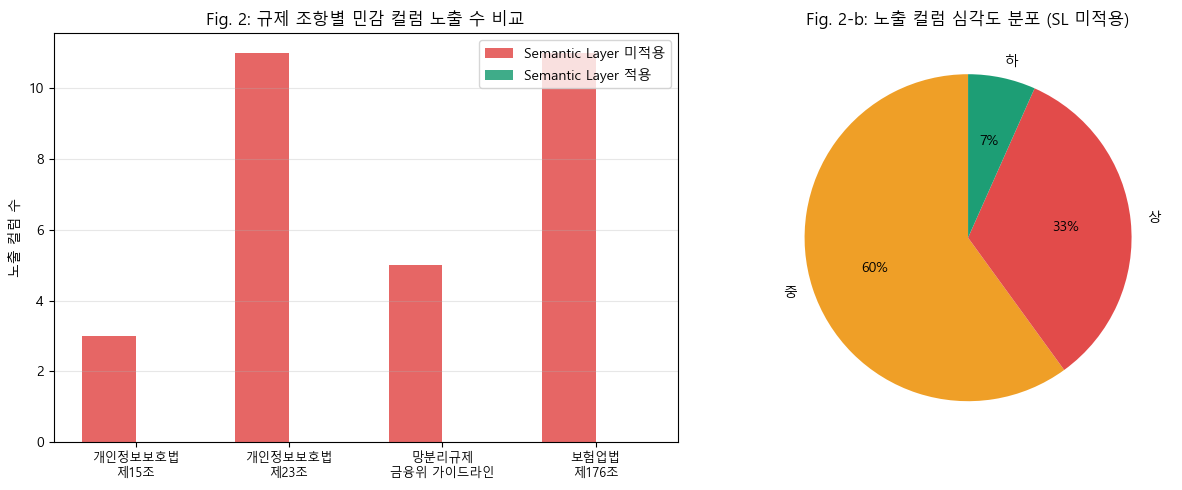

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# 왼쪽: 규제 조항별 노출 수 비교
labels = df_compare['규제'] + '\n' + df_compare['조항']
x = range(len(labels))
w = 0.35

axes[0].bar([i - w/2 for i in x], df_compare['SL 미적용 (노출)'],
            width=w, label='Semantic Layer 미적용', color='#E24B4A', alpha=0.85)
axes[0].bar([i + w/2 for i in x], df_compare['SL 적용 (노출)'],
            width=w, label='Semantic Layer 적용',   color='#1D9E75', alpha=0.85)
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(labels, fontsize=9)
axes[0].set_ylabel('노출 컬럼 수')
axes[0].set_title('Fig. 2: 규제 조항별 민감 컬럼 노출 수 비교')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# 오른쪽: 심각도별 파이차트
sev_counts = df_before['severity'].value_counts()
colors_pie = [SEVERITY_COLOR.get(s, '#888') for s in sev_counts.index]
axes[1].pie(sev_counts.values, labels=sev_counts.index,
            colors=colors_pie, autopct='%1.0f%%', startangle=90)
axes[1].set_title('Fig. 2-b: 노출 컬럼 심각도 분포 (SL 미적용)')

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'exp1_exposure_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

In [6]:
SCENARIOS = {
    "A_cloud_without_sl": {
        "label":   "클라우드 LLM + SL 미적용",
        "network": "외부망",
        "context_columns": [
            # 실제 DB 컬럼명 기준
            "insured_name", "birth_date", "gender",
            "diagnosis_code", "prior_diagnosis_code", "icd_code",
            "death_cause", "disability_type",
            "monthly_premium", "paid_amount", "claim_denial_reason",
            "premium_surcharge_rate", "decision_type",
        ],
    },
    "B_cloud_with_sl": {
        "label":   "클라우드 LLM + SL 적용",
        "network": "외부망",
        "context_columns": [
            # Semantic Layer 추상화 후 개념 단위
            "customer_risk_grade",
            "underwriting_outcome",
            "premium_band",
            "claim_outcome",
        ],
    },
    "C_onprem_without_sl": {
        "label":   "온프레미스 LLM + SL 미적용",
        "network": "내부망",
        "context_columns": [
            "insured_name", "birth_date", "gender",
            "diagnosis_code", "prior_diagnosis_code", "icd_code",
            "death_cause", "disability_type",
            "monthly_premium", "paid_amount", "claim_denial_reason",
            "premium_surcharge_rate", "decision_type",
        ],
    },
}

def analyze(name, scenario):
    cols      = scenario["context_columns"]
    sensitive = [c for c in cols if c in REGULATORY_TAG_MAP]
    is_ext    = scenario["network"] == "외부망"
    violation = is_ext and len(sensitive) > 0
    return {
        "scenario_id":         name,
        "label":               scenario["label"],
        "network":             scenario["network"],
        "total_context_cols":  len(cols),
        "sensitive_count":     len(sensitive),
        "sensitive_exposed":   sensitive,
        "ext_transfer_count":  len(cols) if is_ext else 0,
        "violation":           violation,
        "verdict":             "위반" if violation else "준수",
    }

results = [analyze(n, s) for n, s in SCENARIOS.items()]

print('=' * 60)
print('  실험 2: 망분리 시나리오')
print('=' * 60)
for r in results:
    print()
    print('[' + r['label'] + ']')
    print('  네트워크:', r['network'],
          '| 민감 컬럼 노출:', r['sensitive_count'], '개',
          '| 외부망 전송:', r['ext_transfer_count'], '개',
          '| 판정:', r['verdict'])
    for c in r['sensitive_exposed']:
        tag = REGULATORY_TAG_MAP[c]
        print('    -', c, '(' + tag['law'], tag['article'] + ', 심각도:', tag['severity'] + ')')
print()

  실험 2: 망분리 시나리오

[클라우드 LLM + SL 미적용]
  네트워크: 외부망 | 민감 컬럼 노출: 13 개 | 외부망 전송: 13 개 | 판정: 위반
    - insured_name (개인정보보호법 제15조, 심각도: 중)
    - birth_date (개인정보보호법 제15조, 심각도: 중)
    - gender (개인정보보호법 제15조, 심각도: 하)
    - diagnosis_code (개인정보보호법 제23조, 심각도: 상)
    - prior_diagnosis_code (개인정보보호법 제23조, 심각도: 상)
    - icd_code (개인정보보호법 제23조, 심각도: 상)
    - death_cause (개인정보보호법 제23조, 심각도: 상)
    - disability_type (개인정보보호법 제23조, 심각도: 상)
    - monthly_premium (보험업법 제176조, 심각도: 중)
    - paid_amount (보험업법 제176조, 심각도: 중)
    - claim_denial_reason (보험업법 제176조, 심각도: 중)
    - premium_surcharge_rate (보험업법 제176조, 심각도: 중)
    - decision_type (보험업법 제176조, 심각도: 중)

[클라우드 LLM + SL 적용]
  네트워크: 외부망 | 민감 컬럼 노출: 0 개 | 외부망 전송: 4 개 | 판정: 준수

[온프레미스 LLM + SL 미적용]
  네트워크: 내부망 | 민감 컬럼 노출: 13 개 | 외부망 전송: 0 개 | 판정: 준수
    - insured_name (개인정보보호법 제15조, 심각도: 중)
    - birth_date (개인정보보호법 제15조, 심각도: 중)
    - gender (개인정보보호법 제15조, 심각도: 하)
    - diagnosis_code (개인정보보호법 제23조, 심각도: 상)
    - prior_diagnosis_code (개인정보보호법 제23조, 심각도:

=== Table 4: 실험 2 결과 비교표 ===

              시나리오 네트워크  민감 컬럼 노출  외부망 전송 컬럼 망분리 판정
 클라우드 LLM + SL 미적용  외부망        13         13     위반
  클라우드 LLM + SL 적용  외부망         0          4     준수
온프레미스 LLM + SL 미적용  내부망        13          0     준수


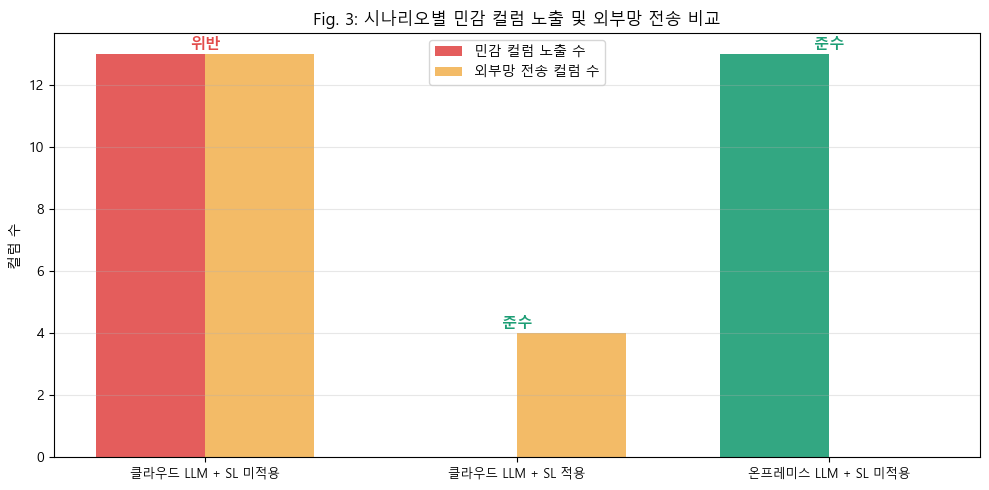

In [7]:
df_exp2 = pd.DataFrame([{
    '시나리오':         r['label'],
    '네트워크':         r['network'],
    '민감 컬럼 노출':   r['sensitive_count'],
    '외부망 전송 컬럼': r['ext_transfer_count'],
    '망분리 판정':      r['verdict'],
} for r in results])

print('=== Table 4: 실험 2 결과 비교표 ===')
print()
print(df_exp2.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
x = range(len(results))
w = 0.35
colors_bar = ['#E24B4A' if r['violation'] else '#1D9E75' for r in results]

ax.bar([i - w/2 for i in x],
       [r['sensitive_count'] for r in results],
       width=w, label='민감 컬럼 노출 수', color=colors_bar, alpha=0.9)
ax.bar([i + w/2 for i in x],
       [r['ext_transfer_count'] for r in results],
       width=w, label='외부망 전송 컬럼 수', color='#EF9F27', alpha=0.7)

ax.set_xticks(list(x))
ax.set_xticklabels([r['label'] for r in results], fontsize=9)
ax.set_ylabel('컬럼 수')
ax.set_title('Fig. 3: 시나리오별 민감 컬럼 노출 및 외부망 전송 비교')
ax.legend()
ax.grid(axis='y', alpha=0.3)

for i, r in enumerate(results):
    y = max(r['sensitive_count'], r['ext_transfer_count']) + 0.15
    ax.text(i, y, r['verdict'], ha='center', fontsize=11, fontweight='bold',
            color='#E24B4A' if r['violation'] else '#1D9E75')

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'exp2_network_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

In [8]:
CHECKLIST = [
    {
        "id": "REQ-01", "regulation": "개인정보보호법", "article": "제23조",
        "requirement": "민감정보 최소 노출",
        "solution": "Semantic Layer (스키마 추상화)",
        "before": "미충족", "after": "충족",
        "evidence": "실험 1: SL 적용 후 민감 컬럼 노출 0개",
    },
    {
        "id": "REQ-02", "regulation": "개인정보보호법", "article": "제15조",
        "requirement": "개인정보 최소수집",
        "solution": "Semantic Layer (개인식별 컬럼 추상화)",
        "before": "미충족", "after": "충족",
        "evidence": "실험 1: insured_name→customer_id, birth_date→age_band 추상화",
    },
    {
        "id": "REQ-03", "regulation": "보험업법", "article": "제176조",
        "requirement": "보험정보 제3자 제공 제한",
        "solution": "온프레미스 LLM",
        "before": "미충족", "after": "충족 (온프레미스 전환 시)",
        "evidence": "실험 2: 온프레미스 LLM 사용 시 외부 전송 0건",
    },
    {
        "id": "REQ-04", "regulation": "망분리규제", "article": "금융위 가이드",
        "requirement": "외부망 민감정보 전송 금지",
        "solution": "온프레미스 LLM",
        "before": "미충족", "after": "충족 (온프레미스 전환 시)",
        "evidence": "실험 2: 클라우드 LLM 시나리오 모두 망분리 위반",
    },
    {
        "id": "REQ-05", "regulation": "AI 기본법", "article": "제10·11조",
        "requirement": "고영향 AI 설명가능성·감사추적",
        "solution": "프롬프트 로깅 + 감사 이력 관리",
        "before": "미충족", "after": "충족 (로깅 구현 시)",
        "evidence": "프롬프트-응답 이력 DB 저장으로 감사 추적 구현 가능",
    },
]

df_exp3 = pd.DataFrame(CHECKLIST)

print('=' * 60)
print('  실험 3: 규제 요건-기술 솔루션 매핑')
print('=' * 60)
for _, r in df_exp3.iterrows():
    mark = 'O' if '충족' in r['after'] else 'X'
    print()
    print('[' + r['id'] + '] ' + r['regulation'] + ' ' + r['article'])
    print('  요건:', r['requirement'])
    print('  기술:', r['solution'])
    print('  적용 전:', r['before'], '→ 적용 후:', r['after'], '[' + mark + ']')
    print('  근거:', r['evidence'])

improved = sum(1 for _, r in df_exp3.iterrows() if '충족' in r['after'])
print()
print('총', len(df_exp3), '개 요건 중', improved, '개 기술적 해소 확인')

  실험 3: 규제 요건-기술 솔루션 매핑

[REQ-01] 개인정보보호법 제23조
  요건: 민감정보 최소 노출
  기술: Semantic Layer (스키마 추상화)
  적용 전: 미충족 → 적용 후: 충족 [O]
  근거: 실험 1: SL 적용 후 민감 컬럼 노출 0개

[REQ-02] 개인정보보호법 제15조
  요건: 개인정보 최소수집
  기술: Semantic Layer (개인식별 컬럼 추상화)
  적용 전: 미충족 → 적용 후: 충족 [O]
  근거: 실험 1: insured_name→customer_id, birth_date→age_band 추상화

[REQ-03] 보험업법 제176조
  요건: 보험정보 제3자 제공 제한
  기술: 온프레미스 LLM
  적용 전: 미충족 → 적용 후: 충족 (온프레미스 전환 시) [O]
  근거: 실험 2: 온프레미스 LLM 사용 시 외부 전송 0건

[REQ-04] 망분리규제 금융위 가이드
  요건: 외부망 민감정보 전송 금지
  기술: 온프레미스 LLM
  적용 전: 미충족 → 적용 후: 충족 (온프레미스 전환 시) [O]
  근거: 실험 2: 클라우드 LLM 시나리오 모두 망분리 위반

[REQ-05] AI 기본법 제10·11조
  요건: 고영향 AI 설명가능성·감사추적
  기술: 프롬프트 로깅 + 감사 이력 관리
  적용 전: 미충족 → 적용 후: 충족 (로깅 구현 시) [O]
  근거: 프롬프트-응답 이력 DB 저장으로 감사 추적 구현 가능

총 5 개 요건 중 5 개 기술적 해소 확인


=== Table 5: 규제 요건-기술 솔루션 매핑표 ===

| ID     | 규제           | 조항          | 요건                          | 기술 솔루션                           | 적용 전   | 적용 후                   | 실험 근거                                                    |
|:-------|:---------------|:--------------|:------------------------------|:--------------------------------------|:----------|:--------------------------|:-------------------------------------------------------------|
| REQ-01 | 개인정보보호법 | 제23조        | 민감정보 최소 노출            | Semantic Layer (스키마 추상화)        | 미충족    | 충족                      | 실험 1: SL 적용 후 민감 컬럼 노출 0개                        |
| REQ-02 | 개인정보보호법 | 제15조        | 개인정보 최소수집             | Semantic Layer (개인식별 컬럼 추상화) | 미충족    | 충족                      | 실험 1: insured_name→customer_id, birth_date→age_band 추상화 |
| REQ-03 | 보험업법       | 제176조       | 보험정보 제3자 제공 제한      | 온프레미스 LLM                        | 미충족    | 충족 (온프레미스 전환 시) | 실험 2: 온프레미스 LLM 사용 시 외부 전송 0건                 |
| REQ-04 | 망분리규제

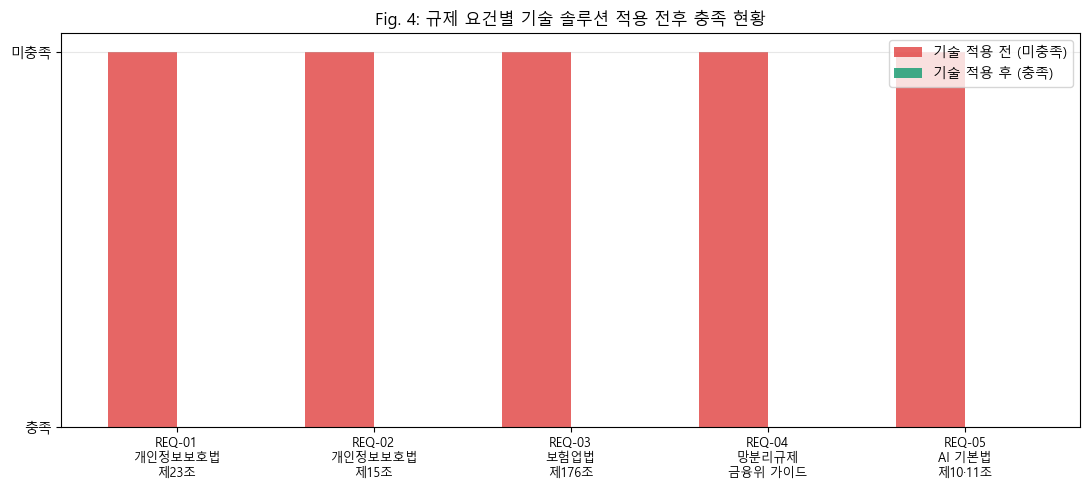

In [9]:
# Table 5 마크다운 (논문 복사용)
table5 = df_exp3[['id','regulation','article','requirement',
                   'solution','before','after','evidence']].copy()
table5.columns = ['ID','규제','조항','요건','기술 솔루션','적용 전','적용 후','실험 근거']
print('=== Table 5: 규제 요건-기술 솔루션 매핑표 ===')
print()
print(table5.to_markdown(index=False))

# 시각화
fig, ax = plt.subplots(figsize=(11, 5))
x = range(len(df_exp3))
w = 0.35

ax.bar([i - w/2 for i in x], [1]*len(df_exp3),
       width=w, label='기술 적용 전 (미충족)', color='#E24B4A', alpha=0.85)
ax.bar([i + w/2 for i in x], [0]*len(df_exp3),
       width=w, label='기술 적용 후 (충족)',   color='#1D9E75', alpha=0.85)

ax.set_xticks(list(x))
ax.set_xticklabels(
    [r['id'] + '\n' + r['regulation'] + '\n' + r['article']
     for _, r in df_exp3.iterrows()],
    fontsize=9
)
ax.set_yticks([0, 1])
ax.set_yticklabels(['충족', '미충족'])
ax.set_title('Fig. 4: 규제 요건별 기술 솔루션 적용 전후 충족 현황')
ax.legend()
ax.grid(axis='y', alpha=0.3)

solutions = ['Semantic\nLayer', 'Semantic\nLayer',
             '온프레미스\nLLM', '온프레미스\nLLM', '프롬프트\n로깅']
for i, sol in enumerate(solutions):
    ax.text(i + w/2, 0.05, sol, ha='center', va='bottom',
            fontsize=8, color='white', fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'exp3_compliance_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

In [10]:
print('=' * 60)
print('  전체 실험 소결')
print('=' * 60)
print()
print('[실험 1] 민감정보 노출 측정')
print('  SL 미적용 노출 컬럼:', len(df_before), '개')
print('  SL 적용 노출 컬럼:   0개')
print('  개인정보보호법 제23조 충족: 미충족 → 충족')
print()
print('[실험 2] 망분리 시나리오')
for r in results:
    print('  ' + r['label'] + ':', r['verdict'])
print()
print('[실험 3] 규제 요건-기술 솔루션 매핑')
print('  5개 요건 모두 기술적 해소 확인')
print()
print('[결론]')
print('  단일 기술로 모든 규제 요건 충족 불가')
print('  Semantic Layer + 온프레미스 LLM + 프롬프트 로깅 3중 아키텍처 필요')
print('  → 5장 3단계 거버넌스 프레임워크 설계의 실증적 근거')

  전체 실험 소결

[실험 1] 민감정보 노출 측정
  SL 미적용 노출 컬럼: 30 개
  SL 적용 노출 컬럼:   0개
  개인정보보호법 제23조 충족: 미충족 → 충족

[실험 2] 망분리 시나리오
  클라우드 LLM + SL 미적용: 위반
  클라우드 LLM + SL 적용: 준수
  온프레미스 LLM + SL 미적용: 준수

[실험 3] 규제 요건-기술 솔루션 매핑
  5개 요건 모두 기술적 해소 확인

[결론]
  단일 기술로 모든 규제 요건 충족 불가
  Semantic Layer + 온프레미스 LLM + 프롬프트 로깅 3중 아키텍처 필요
  → 5장 3단계 거버넌스 프레임워크 설계의 실증적 근거


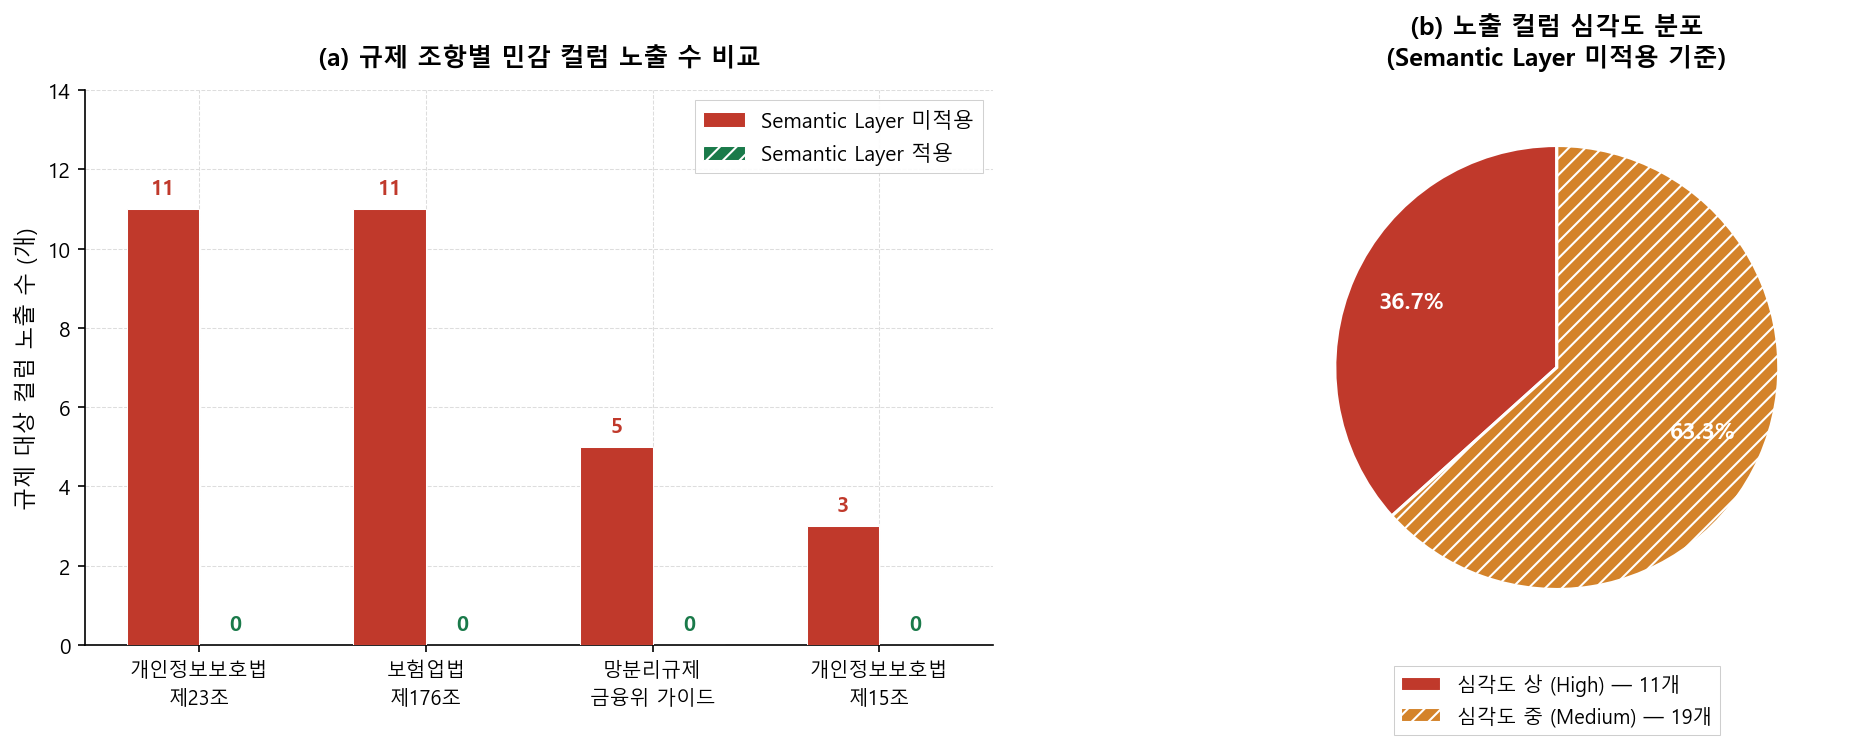

저장 완료: exp1_exposure_comparison.png (600 dpi)


In [19]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as ticker
import numpy as np

plt.rcParams.update({
    'font.family':        'Malgun Gothic',
    'font.size':          11,
    'axes.titlesize':     12,
    'axes.titleweight':   'bold',
    'axes.titlepad':      12,
    'axes.labelsize':     11,
    'axes.spines.top':    False,
    'axes.spines.right':  False,
    'axes.linewidth':     0.8,
    'axes.grid':          True,
    'grid.color':         '#DDDDDD',
    'grid.linewidth':     0.5,
    'grid.linestyle':     '--',
    'xtick.labelsize':    10,
    'ytick.labelsize':    10,
    'legend.fontsize':    10,
    'legend.framealpha':  0.9,
    'legend.edgecolor':   '#CCCCCC',
    'legend.fancybox':    False,
    'figure.dpi':         150,
    'savefig.dpi':        600,
    'savefig.bbox':       'tight',
    'figure.facecolor':   'white',
    'axes.facecolor':     'white',
})

C_RED   = '#C0392B'
C_GREEN = '#1A7A4A'
C_SEV_H = '#C0392B'
C_SEV_M = '#D4832A'

laws   = ['개인정보보호법\n제23조', '보험업법\n제176조',
          '망분리규제\n금융위 가이드', '개인정보보호법\n제15조']
before = [11, 11, 5, 3]
after  = [ 0,  0, 0, 0]
x      = np.arange(len(laws))
w      = 0.32

sev_values = [11, 19]
sev_colors = [C_SEV_H, C_SEV_M]
sev_hatch  = ['', '///']

fig, axes = plt.subplots(1, 2, figsize=(13, 5),
                         gridspec_kw={'width_ratios': [1.6, 1]})
fig.subplots_adjust(left=0.07, right=0.97, bottom=0.18, top=0.92, wspace=0.38)

ax = axes[0]
bars_no  = ax.bar(x - w/2, before, width=w,
                  color=C_RED, edgecolor='white', linewidth=0.5,
                  label='Semantic Layer 미적용', zorder=3)
bars_yes = ax.bar(x + w/2, after, width=w,
                  color=C_GREEN, edgecolor='white', linewidth=0.5,
                  hatch='///', label='Semantic Layer 적용', zorder=3)

for bar in bars_no:
    h = bar.get_height()
    if h > 0:
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.25,
                str(int(h)), ha='center', va='bottom',
                fontsize=10, fontweight='bold', color=C_RED)

for bar in bars_yes:
    ax.text(bar.get_x() + bar.get_width()/2, 0.25,
            '0', ha='center', va='bottom',
            fontsize=10, fontweight='bold', color=C_GREEN)

ax.set_xticks(x)
ax.set_xticklabels(laws, fontsize=9.5, linespacing=1.4)
ax.set_ylabel('규제 대상 컬럼 노출 수 (개)', fontsize=11)
ax.set_ylim(0, 14)
ax.yaxis.set_major_locator(ticker.MultipleLocator(2))
ax.set_title('(a) 규제 조항별 민감 컬럼 노출 수 비교', fontsize=12, fontweight='bold')
ax.legend(loc='upper right').get_frame().set_linewidth(0.5)
ax.set_axisbelow(True)
ax.spines['left'].set_linewidth(0.8)
ax.spines['bottom'].set_linewidth(0.8)

ax2 = axes[1]
wedges, texts, autotexts = ax2.pie(
    sev_values, labels=None,
    colors=sev_colors,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5},
    pctdistance=0.72,
)
for at, hatch in zip(wedges, sev_hatch):
    at.set_hatch(hatch)
for autotext in autotexts:
    autotext.set_fontsize(11)
    autotext.set_fontweight('bold')
    autotext.set_color('white')

legend_handles = [
    mpatches.Patch(facecolor=C_SEV_H, edgecolor='white',
                   label='심각도 상 (High) — 11개'),
    mpatches.Patch(facecolor=C_SEV_M, edgecolor='white',
                   hatch='///', label='심각도 중 (Medium) — 19개'),
]
ax2.legend(handles=legend_handles, loc='lower center',
           bbox_to_anchor=(0.5, -0.18),
           framealpha=0.95, edgecolor='#CCCCCC',
           fancybox=False, fontsize=9.5,
           ncol=1).get_frame().set_linewidth(0.5)
ax2.set_title('(b) 노출 컬럼 심각도 분포\n(Semantic Layer 미적용 기준)',
              fontsize=12, fontweight='bold')

plt.savefig(os.path.join(FIG_DIR, 'exp1_exposure_comparison.png'),
            dpi=600, bbox_inches='tight', facecolor='white')
plt.show()
print('저장 완료: exp1_exposure_comparison.png (600 dpi)')

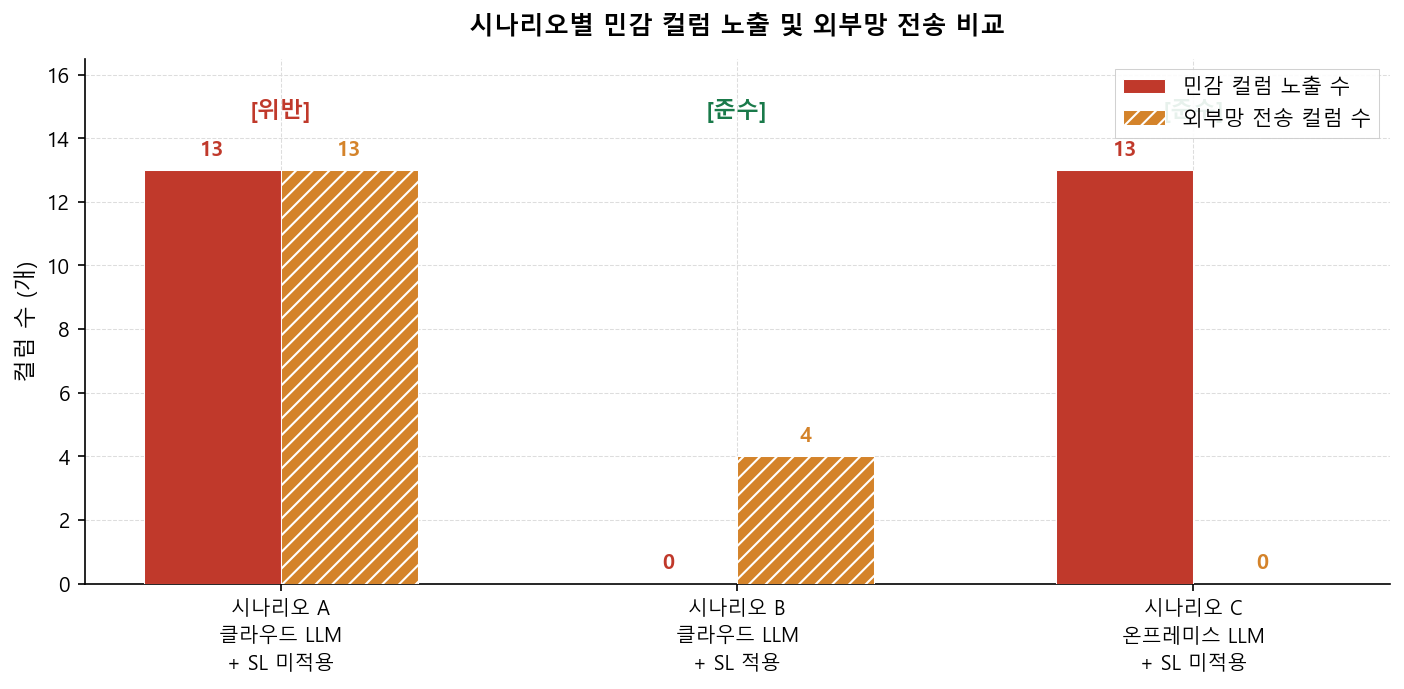

저장 완료: exp2_network_comparison.png (600 dpi)


In [15]:
C_SENS = '#C0392B'
C_EXT  = '#D4832A'

scenarios = ['시나리오 A\n클라우드 LLM\n+ SL 미적용',
             '시나리오 B\n클라우드 LLM\n+ SL 적용',
             '시나리오 C\n온프레미스 LLM\n+ SL 미적용']
sens_vals = [13,  0, 13]
ext_vals  = [13,  4,  0]
verdicts  = ['위반', '준수', '준수']
verdict_c = ['#C0392B', '#1A7A4A', '#1A7A4A']
x3 = np.arange(len(scenarios))
w3 = 0.30

fig2, ax3 = plt.subplots(figsize=(10, 5))
fig2.subplots_adjust(left=0.1, right=0.97, bottom=0.22, top=0.92)

b1 = ax3.bar(x3 - w3/2, sens_vals, width=w3,
             color=C_SENS, edgecolor='white', linewidth=0.5,
             label='민감 컬럼 노출 수', zorder=3)
b2 = ax3.bar(x3 + w3/2, ext_vals, width=w3,
             color=C_EXT, edgecolor='white', linewidth=0.5,
             hatch='///', label='외부망 전송 컬럼 수', zorder=3)

for bar, val in zip(b1, sens_vals):
    ax3.text(bar.get_x() + bar.get_width()/2,
             val + 0.3 if val > 0 else 0.3,
             str(val), ha='center', va='bottom',
             fontsize=10, fontweight='bold', color=C_SENS)

for bar, val in zip(b2, ext_vals):
    ax3.text(bar.get_x() + bar.get_width()/2,
             val + 0.3 if val > 0 else 0.3,
             str(val), ha='center', va='bottom',
             fontsize=10, fontweight='bold', color=C_EXT)

for i, (v, vc) in enumerate(zip(verdicts, verdict_c)):
    ax3.text(i, 14.5, f'[{v}]', ha='center', va='bottom',
             fontsize=11, fontweight='bold', color=vc)

ax3.set_xticks(x3)
ax3.set_xticklabels(scenarios, fontsize=9.5, linespacing=1.4)
ax3.set_ylabel('컬럼 수 (개)', fontsize=11)
ax3.set_ylim(0, 16.5)
ax3.yaxis.set_major_locator(ticker.MultipleLocator(2))
ax3.set_title('시나리오별 민감 컬럼 노출 및 외부망 전송 비교',
              fontsize=12, fontweight='bold')
ax3.legend(loc='upper right').get_frame().set_linewidth(0.5)
ax3.set_axisbelow(True)
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
ax3.spines['left'].set_linewidth(0.8)
ax3.spines['bottom'].set_linewidth(0.8)

plt.savefig(os.path.join(FIG_DIR, 'exp2_network_comparison.png'),
            dpi=600, bbox_inches='tight', facecolor='white')
plt.show()
print('저장 완료: exp2_network_comparison.png (600 dpi)')

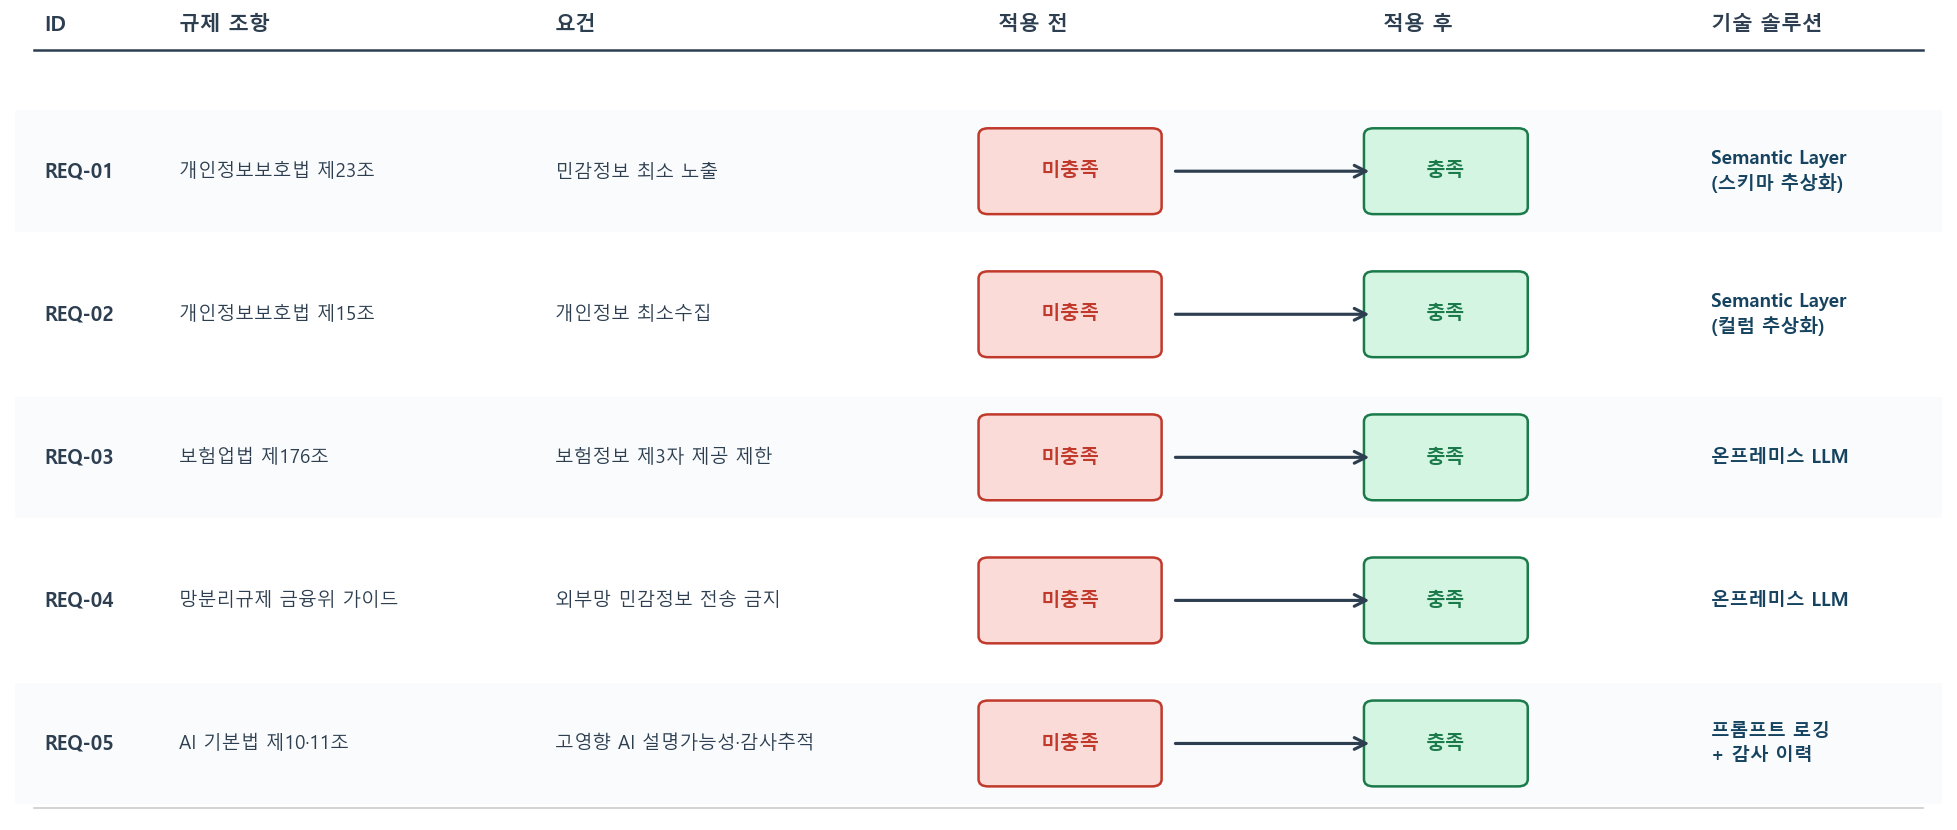

저장 완료: exp3_compliance_comparison.png (600 dpi)


In [17]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch
import numpy as np

plt.rcParams.update({
    'font.family':      'Malgun Gothic',
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
    'savefig.dpi':      600,
    'figure.dpi':       150,
})

reqs = [
    ('REQ-01', '개인정보보호법 제23조', '민감정보 최소 노출',          'Semantic Layer\n(스키마 추상화)'),
    ('REQ-02', '개인정보보호법 제15조', '개인정보 최소수집',            'Semantic Layer\n(컬럼 추상화)'),
    ('REQ-03', '보험업법 제176조',      '보험정보 제3자 제공 제한',     '온프레미스 LLM'),
    ('REQ-04', '망분리규제 금융위 가이드','외부망 민감정보 전송 금지',  '온프레미스 LLM'),
    ('REQ-05', 'AI 기본법 제10·11조',   '고영향 AI 설명가능성·감사추적','프롬프트 로깅\n+ 감사 이력'),
]

C_RED   = '#C0392B'
C_GREEN = '#1A7A4A'
C_ARROW = '#2C3E50'

fig, ax = plt.subplots(figsize=(13, 5.5))
ax.set_xlim(0, 10)
ax.set_ylim(-0.5, len(reqs))
ax.axis('off')

# 컬럼 X 위치
X_ID    = 0.15
X_REG   = 0.85
X_REQ   = 2.8
X_BEFORE= 5.1
X_ARROW = 6.1
X_AFTER = 7.1
X_SOL   = 8.8

# 헤더
header_y = len(reqs) - 0.05
for x_pos, label in [
    (X_ID,    'ID'),
    (X_REG,   '규제 조항'),
    (X_REQ,   '요건'),
    (X_BEFORE,'적용 전'),
    (X_AFTER, '적용 후'),
    (X_SOL,   '기술 솔루션'),
]:
    ax.text(x_pos, header_y, label,
            ha='left', va='bottom', fontsize=10,
            fontweight='bold', color='#2C3E50')

# 헤더 구분선
ax.axhline(y=len(reqs) - 0.15, xmin=0.01, xmax=0.99,
           color='#2C3E50', linewidth=1.2)

# 행별 내용
for i, (rid, reg, req, sol) in enumerate(reversed(reqs)):
    y = i
    row_bg = '#F8F9FA' if i % 2 == 0 else 'white'
    ax.barh(y, 10, left=0, height=0.85, color=row_bg,
            alpha=0.6, zorder=0)

    # ID
    ax.text(X_ID, y, rid, ha='left', va='center',
            fontsize=9.5, fontweight='bold', color='#2C3E50')

    # 규제 조항
    ax.text(X_REG, y, reg, ha='left', va='center',
            fontsize=9, color='#2C3E50')

    # 요건
    ax.text(X_REQ, y, req, ha='left', va='center',
            fontsize=9, color='#2C3E50')

    # 적용 전: 미충족 배지
    badge_before = mpatches.FancyBboxPatch(
        (X_BEFORE - 0.05, y - 0.25), 0.85, 0.5,
        boxstyle="round,pad=0.05",
        facecolor='#FADBD8', edgecolor=C_RED, linewidth=1.2
    )
    ax.add_patch(badge_before)
    ax.text(X_BEFORE + 0.375, y, '미충족',
            ha='center', va='center', fontsize=9.5,
            fontweight='bold', color=C_RED)

    # 화살표
    ax.annotate('', xy=(X_AFTER - 0.05, y),
                xytext=(X_BEFORE + 0.9, y),
                arrowprops=dict(arrowstyle='->', color=C_ARROW,
                                lw=1.5, mutation_scale=14))

    # 적용 후: 충족 배지
    badge_after = mpatches.FancyBboxPatch(
        (X_AFTER - 0.05, y - 0.25), 0.75, 0.5,
        boxstyle="round,pad=0.05",
        facecolor='#D5F5E3', edgecolor=C_GREEN, linewidth=1.2
    )
    ax.add_patch(badge_after)
    ax.text(X_AFTER + 0.325, y, '충족',
            ha='center', va='center', fontsize=9.5,
            fontweight='bold', color=C_GREEN)

    # 기술 솔루션
    ax.text(X_SOL, y, sol, ha='left', va='center',
            fontsize=9, color='#154360',
            fontweight='bold', linespacing=1.4)

# 하단 구분선
ax.axhline(y=-0.45, xmin=0.01, xmax=0.99,
           color='#CCCCCC', linewidth=0.8)

plt.tight_layout(pad=0.5)
plt.savefig(os.path.join(FIG_DIR, 'exp3_compliance_comparison.png'),
            dpi=600, bbox_inches='tight', facecolor='white')
plt.show()
print('저장 완료: exp3_compliance_comparison.png (600 dpi)')